In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


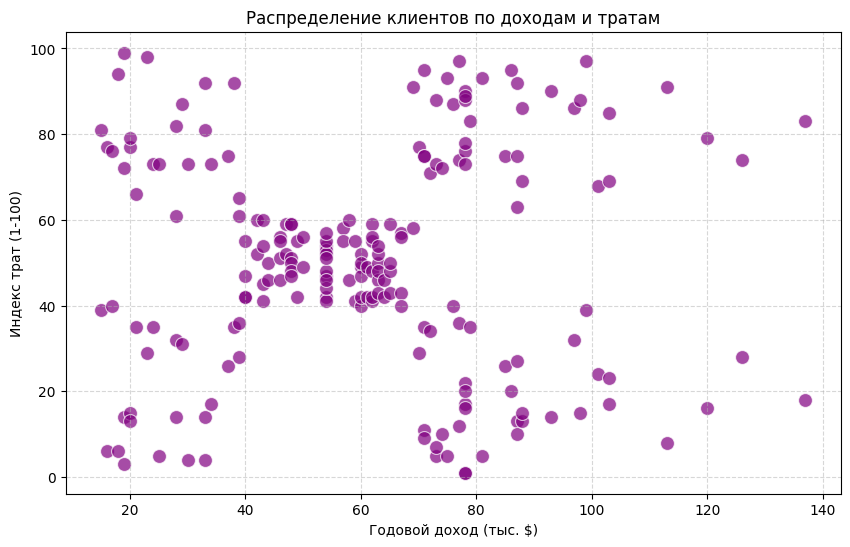

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    s=100, 
    color='purple', 
    alpha=0.7
)


plt.title('Распределение клиентов по доходам и тратам')
plt.xlabel('Годовой доход (тыс. $)')
plt.ylabel('Индекс трат (1-100)')
plt.grid(True, linestyle='--', alpha=0.5)


plt.show()


In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [11]:
from sklearn.cluster import KMeans

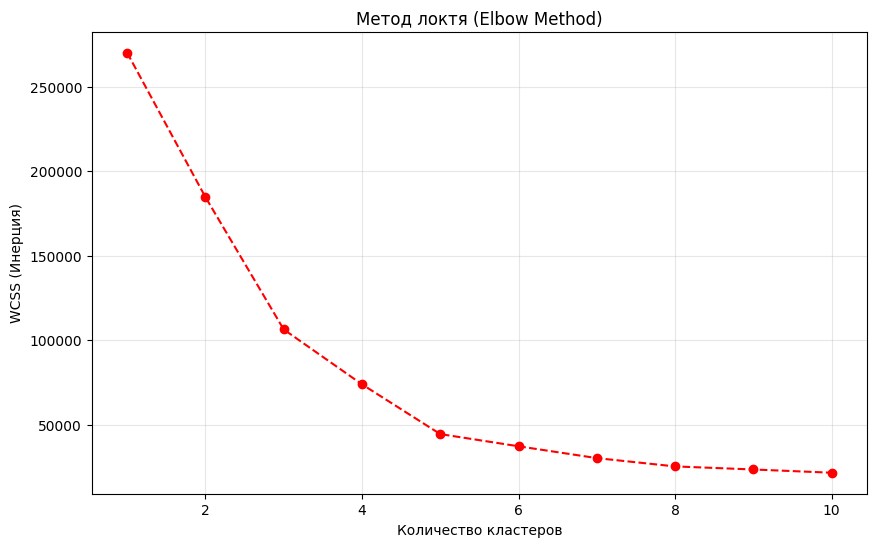

In [19]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init= "k-means++",random_state=101)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('Метод локтя (Elbow Method)')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS (Инерция)')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=101)

In [22]:
df['cluster'] = kmeans_final.fit_predict(X)

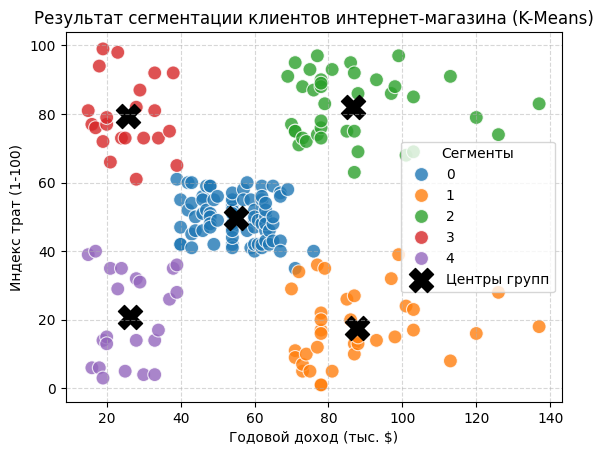

In [ ]:

sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='cluster', 
    palette='tab10', 
    s=100, 
    alpha=0.8
)
centroids = kmeans_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Центры групп')

plt.title('Результат сегментации клиентов интернет-магазина (K-Means)')
plt.xlabel('Годовой доход (тыс. $)')
plt.ylabel('Индекс трат (1-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Сегменты")
plt.show()